# Part 1k: Multi-Modal Data Augmentation & Classification

**Objective:** Demonstrate data augmentation for Image, Text, Tabular, and Time Series data using various libraries.

---

In [ ]:
!pip install nlpaug albumentations -q
import numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(f"TF: {tf.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 9.0 MB/s eta 0:00:00
TF: 2.19.0


## 1. Image Augmentation with TensorFlow & Albumentations

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


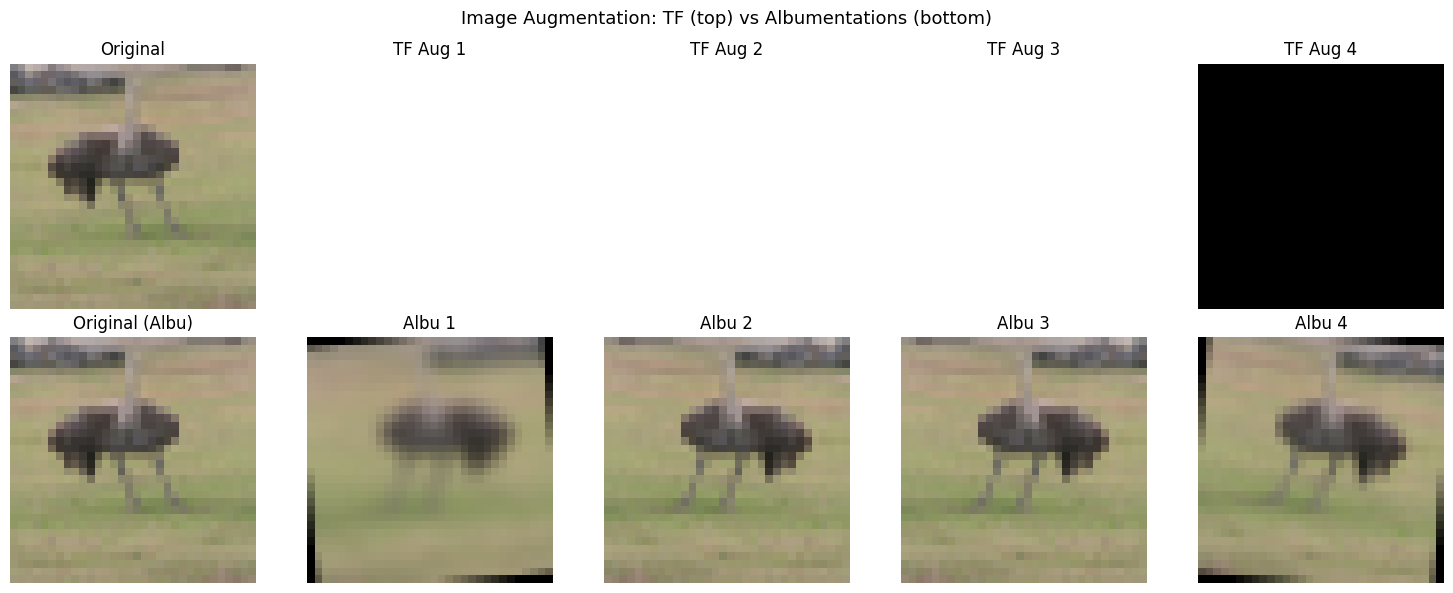

In [ ]:
# Image augmentation using tf.keras preprocessing layers
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32")/255.0, X_test.astype("float32")/255.0
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# TF native augmentation (Keras 3 compatible layers only)
img_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.1),
])

# Visualize
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
img = X_train[42]
axes[0][0].imshow(img); axes[0][0].set_title("Original"); axes[0][0].axis('off')
for i in range(1, 5):
    aug = img_augmentation(tf.expand_dims(img, 0), training=True)[0]
    axes[0][i].imshow(tf.clip_by_value(aug, 0, 1).numpy()); axes[0][i].set_title(f"TF Aug {i}"); axes[0][i].axis('off')

# With Albumentations (v2 compatible API)
import albumentations as A
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.Rotate(limit=15, p=0.5),
])
img_uint8 = (img * 255).astype(np.uint8)
axes[1][0].imshow(img); axes[1][0].set_title("Original (Albu)"); axes[1][0].axis('off')
for i in range(1, 5):
    aug = transform(image=img_uint8)['image']
    axes[1][i].imshow(aug); axes[1][i].set_title(f"Albu {i}"); axes[1][i].axis('off')
plt.suptitle('Image Augmentation: TF (top) vs Albumentations (bottom)', fontsize=13)
plt.tight_layout(); plt.show()

## 2. Text Augmentation with nlpaug

In [ ]:
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac

text = "The quick brown fox jumps over the lazy dog near the river bank."
print(f"Original: {text}\n")

# Synonym replacement (substitute words with WordNet synonyms)
syn_aug = naw.SynonymAug(aug_src='wordnet')
for i in range(3):
    print(f"Synonym {i+1}: {syn_aug.augment(text)[0]}")

# Random word swap (shuffle word positions)
swap_aug = naw.RandomWordAug(action='swap')
print(f"\nRandom Swap: {swap_aug.augment(text)[0]}")

# Random word deletion
delete_aug = naw.RandomWordAug(action='delete')
print(f"Random Delete: {delete_aug.augment(text)[0]}")

# Contextual word insertion (uses a small BERT model — takes a moment to load)
try:
    context_aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action='insert', top_k=5)
    print(f"\nContextual Insert: {context_aug.augment(text)[0]}")
except Exception as e:
    print(f"\nContextual Insert skipped (model download issue): {e}")

# Character-level augmentation (typos)
char_aug = nac.RandomCharAug(action='substitute', aug_char_min=1, aug_char_max=2)
print(f"\nChar Substitute: {char_aug.augment(text)[0]}")

Original: The quick brown fox jumps over the lazy dog near the river bank.

Synonym 1: The spry robert brown fox jumps all over the indolent dog near the river coin bank.
Synonym 2: The quick john brown fox jump over the otiose frank near the river bank.
Synonym 3: The quick brownness fox startle all over the lazy click near the river depository financial institution.

Random Swap: Quick brown the jumps fox over lazy the dog near the river. bank
Random Delete: The quick fox jumps over lazy river bank.


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Contextual Insert skipped (model download issue): BertTokenizer has no attribute _convert_token_to_id

Char Substitute: The %uiZk brown fox j@@ps over the lmzy dog ner3 the river #anj.


## 3. Text Classification A/B Test (IMDB)

In [ ]:
# Text classification A/B test: IMDB sentiment with/without augmentation
import tensorflow_datasets as tfds

# Load a small subset of IMDB
(train_data, test_data), info = tfds.load('imdb_reviews', split=['train[:5000]', 'test[:1000]'],
                                           as_supervised=True, with_info=True)

# Vectorize text
vectorizer = layers.TextVectorization(max_tokens=10000, output_sequence_length=200)
train_texts = [tx.numpy().decode('utf-8') for tx, _ in train_data]
vectorizer.adapt(train_texts)

def build_text_model():
    model = keras.Sequential([
        layers.Input(shape=(200,)),
        layers.Embedding(10000, 64),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Prepare data
X_texts = np.array(train_texts)
y_labels = np.array([label.numpy() for _, label in train_data])
X_vec = vectorizer(X_texts).numpy()

X_test_texts = np.array([tx.numpy().decode('utf-8') for tx, _ in test_data])
y_test_labels = np.array([lb.numpy() for _, lb in test_data])
X_test_vec = vectorizer(X_test_texts).numpy()

# Without augmentation
print("=== Without Text Augmentation ===")
m1 = build_text_model()
m1.fit(X_vec, y_labels, epochs=5, batch_size=64, validation_split=0.2, verbose=1)
_, acc1 = m1.evaluate(X_test_vec, y_test_labels, verbose=0)
print(f"Test Accuracy: {acc1:.4f}")

# With augmentation (augment training text with synonyms)
print("\n=== With Text Augmentation (Synonym) ===")
text_aug = naw.SynonymAug(aug_src='wordnet')
aug_texts_list = []
aug_labels_list = []
for txt, lbl in zip(X_texts[:1000], y_labels[:1000]):
    aug_t = text_aug.augment(txt)[0]
    aug_texts_list.append(aug_t)
    aug_labels_list.append(lbl)

X_combined = np.concatenate([X_texts, np.array(aug_texts_list)])
y_combined = np.concatenate([y_labels, np.array(aug_labels_list)])
X_combined_vec = vectorizer(X_combined).numpy()

m2 = build_text_model()
m2.fit(X_combined_vec, y_combined, epochs=5, batch_size=64, validation_split=0.2, verbose=1)
_, acc2 = m2.evaluate(X_test_vec, y_test_labels, verbose=0)
print(f"Test Accuracy: {acc2:.4f}")
print(f"\nDifference: {(acc2-acc1)*100:+.2f}%")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.1SZ10H_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.1SZ10H_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.1SZ10H_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
=== Without Text Augmentation ===
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.5525 - loss: 0.6889 - val_accuracy: 0.6400 - val_loss: 0.6794
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6908 - loss: 0.6448 - val_accuracy: 0.7390 - val_loss: 0.6018
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7793 - loss: 0.5229 - val_accuracy: 0.7730 - val_loss: 0.4837
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8495 - loss: 0.3840 - val_accuracy: 0.8250 - val_loss: 0.4079
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8990 - loss: 0.2867 - val_accuracy: 0.8000 - val_loss: 0.4199
Test Accuracy: 0.7720

=== With Text Augmentation (Synonym) ===
Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5773 - loss: 0.6876 - val_accuracy: 0.7025 - val_loss: 0.6676
Epoch 

## 4. Tabular Data Augmentation (Gaussian Noise Injection)

In [ ]:
# Tabular augmentation via noise injection
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_tab, y_tab = make_classification(n_samples=1000, n_features=20, n_classes=5,
                                    n_informative=15, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_tab, y_tab, test_size=0.2, random_state=42)

def augment_tabular(X, y, noise_std=0.1, n_copies=2):
    aug_X, aug_y = [X], [y]
    for _ in range(n_copies):
        noise = np.random.normal(0, noise_std, X.shape)
        aug_X.append(X + noise)
        aug_y.append(y)
    return np.vstack(aug_X), np.concatenate(aug_y)

# Without augmentation
m_no = keras.Sequential([layers.Input(shape=(20,)), layers.Dense(64, activation='relu'),
                          layers.Dense(32, activation='relu'), layers.Dense(5, activation='softmax')])
m_no.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
m_no.fit(X_tr, y_tr, epochs=10, batch_size=32, verbose=0)
_, acc_no = m_no.evaluate(X_te, y_te, verbose=0)

# With augmentation
X_aug, y_aug = augment_tabular(X_tr, y_tr, noise_std=0.05, n_copies=3)
m_aug = keras.Sequential([layers.Input(shape=(20,)), layers.Dense(64, activation='relu'),
                           layers.Dense(32, activation='relu'), layers.Dense(5, activation='softmax')])
m_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
m_aug.fit(X_aug, y_aug, epochs=10, batch_size=32, verbose=0)
_, acc_aug = m_aug.evaluate(X_te, y_te, verbose=0)

print(f"Tabular — No Aug: {acc_no:.4f}, With Aug: {acc_aug:.4f}")

Tabular — No Aug: 0.6500, With Aug: 0.7750


## 5. Time Series Augmentation

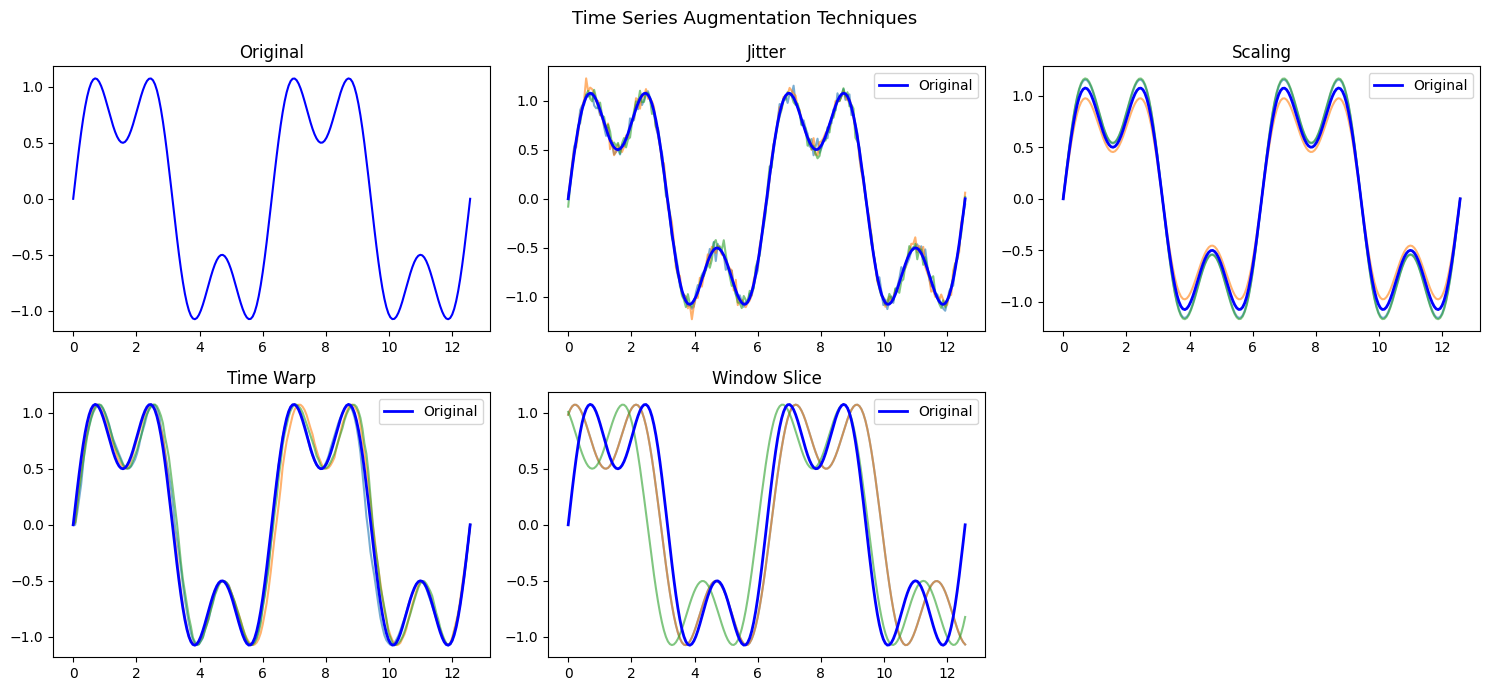

In [ ]:
# Time series augmentation techniques
np.random.seed(42)
t = np.linspace(0, 4*np.pi, 200)
signal = np.sin(t) + 0.5*np.sin(3*t)

def ts_jitter(x, sigma=0.05):
    return x + np.random.normal(0, sigma, len(x))

def ts_scaling(x, sigma=0.1):
    return x * np.random.normal(1, sigma)

def ts_time_warp(x, sigma=0.2):
    warp = np.cumsum(np.random.normal(1, sigma, len(x)))
    warp = warp / warp[-1] * (len(x) - 1)
    return np.interp(np.arange(len(x)), warp, x)

def ts_window_slice(x, ratio=0.9):
    length = int(len(x) * ratio)
    start = np.random.randint(0, len(x) - length)
    sliced = x[start:start+length]
    return np.interp(np.linspace(0, length-1, len(x)), np.arange(length), sliced)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes[0][0].plot(t, signal, 'b-'); axes[0][0].set_title('Original')
augs = [('Jitter', ts_jitter), ('Scaling', ts_scaling), ('Time Warp', ts_time_warp),
        ('Window Slice', ts_window_slice)]
for ax, (name, fn) in zip([axes[0][1], axes[0][2], axes[1][0], axes[1][1]], augs):
    for i in range(3): ax.plot(t, fn(signal), alpha=0.6)
    ax.plot(t, signal, 'b-', linewidth=2, label='Original')
    ax.set_title(name); ax.legend()
axes[1][2].axis('off')
plt.suptitle('Time Series Augmentation Techniques', fontsize=13)
plt.tight_layout(); plt.show()

## Key Takeaways
- **Image**: RandomFlip, Rotation, Zoom, Albumentations (CoarseDropout, GaussNoise)
- **Text**: nlpaug synonym replacement, random insertion/deletion, character augmentation
- **Tabular**: Gaussian noise injection, SMOTE for class imbalance
- **Time Series**: Jittering, scaling, time warping, window slicing
- Augmentation is most beneficial when training data is limited
- Always validate that augmentations preserve label correctness